<a href="https://colab.research.google.com/github/kartikmeghwal75/CODESOFT/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
train_df = pd.read_csv("/content/fraudTrain[1].csv")
test_df = pd.read_csv("/content/fraudTest[1].csv")

In [4]:
print(train_df.head())
print(train_df.shape)

print(train_df.info())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

In [5]:
train_df["is_fraud"].value_counts()

,count
is_fraud,
0.0,161631
1.0,1474


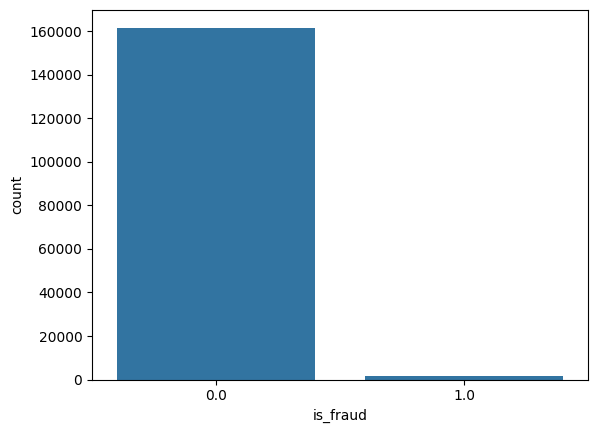

In [6]:
sns.countplot(x="is_fraud", data=train_df)
plt.show()

In [7]:
train_df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [8]:
train_df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_9436/3807834153.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df.fillna(method='ffill', inplace=True)


In [9]:
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)

In [10]:
for df in [train_df, test_df]:

    df["hour"] = df["trans_date_trans_time"].dt.hour

    df["day"] = df["trans_date_trans_time"].dt.day

    df["month"] = df["trans_date_trans_time"].dt.month

    df["weekday"] = df["trans_date_trans_time"].dt.weekday

In [11]:
drop_cols = [

    "Unnamed: 0",

    "trans_date_trans_time",

    "first",
    "last",

    "street",

    "trans_num",

    "cc_num"
]

In [12]:
train_df.drop(columns=drop_cols,
              inplace=True)

test_df.drop(columns=drop_cols,
             inplace=True)

In [13]:
cat_cols = train_df.select_dtypes(
    include="object"
).columns

In [15]:
le = LabelEncoder()

for col in cat_cols:

    train_df[col] = le.fit_transform(
        train_df[col].astype(str)
    )

    test_df[col] = le.fit_transform(
        test_df[col].astype(str)
    )

In [16]:
X_train = train_df.drop("is_fraud", axis=1)

y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)

y_test = test_df["is_fraud"]

In [17]:
X_train = train_df.drop("is_fraud", axis=1)

y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)

y_test = test_df["is_fraud"]

In [21]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Fill NaN values in X_test before prediction
X_test.fillna(method='ffill', inplace=True)
X_test.fillna(method='bfill', inplace=True)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

/tmp/ipykernel_9436/648448664.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test.fillna(method='ffill', inplace=True)
/tmp/ipykernel_9436/648448664.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test.fillna(method='bfill', inplace=True)


In [23]:
y_test_cleaned = y_test.dropna()
pred_lr_cleaned = pd.Series(pred_lr).loc[y_test_cleaned.index]

# Convert to numpy arrays to ensure no pandas-specific indexing issues remain for sklearn
print(classification_report(
    y_test_cleaned.values,
    pred_lr_cleaned.values
))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    405147
         1.0       0.07      0.75      0.12      1887

    accuracy                           0.95    407034
   macro avg       0.53      0.85      0.55    407034
weighted avg       0.99      0.95      0.97    407034



In [24]:
dt = DecisionTreeClassifier(
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [27]:
y_test_cleaned = y_test.dropna()
pred_dt_cleaned = pd.Series(pred_dt).loc[y_test_cleaned.index]

print(classification_report(
    y_test_cleaned.values,
    pred_dt_cleaned.values
))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00    405147
         1.0       0.34      0.65      0.45      1887

    accuracy                           0.99    407034
   macro avg       0.67      0.82      0.72    407034
weighted avg       1.00      0.99      0.99    407034



In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [29]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [30]:
pred_rf = rf.predict(X_test)

In [32]:
combined_df = pd.DataFrame({'y_true': y_test, 'y_pred': pred_rf})
combined_df_cleaned = combined_df.dropna()

y_true_final = combined_df_cleaned['y_true'].values
y_pred_final = combined_df_cleaned['y_pred'].values

print(classification_report(
    y_true_final,
    y_pred_final
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    405147
         1.0       0.98      0.14      0.24      1887

    accuracy                           1.00    407034
   macro avg       0.99      0.57      0.62    407034
weighted avg       1.00      1.00      0.99    407034



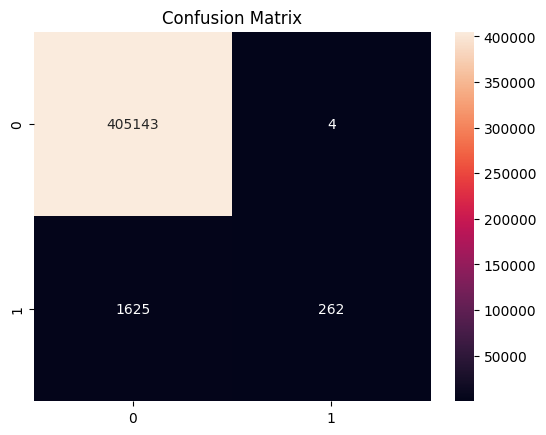

In [34]:
combined_df_for_cm = pd.DataFrame({'y_true': y_test, 'y_pred': pred_rf})
combined_df_cleaned_for_cm = combined_df_for_cm.dropna()

cm = confusion_matrix(
    combined_df_cleaned_for_cm['y_true'].values,
    combined_df_cleaned_for_cm['y_pred'].values
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [36]:
prob = rf.predict_proba(X_test)[:,1]

combined_df_for_auc = pd.DataFrame({'y_true': y_test, 'y_score': prob})
combined_df_cleaned_for_auc = combined_df_for_auc.dropna()

auc = roc_auc_score(
    combined_df_cleaned_for_auc['y_true'].values,
    combined_df_cleaned_for_auc['y_score'].values
)

print("ROC AUC:", auc)

ROC AUC: 0.9687397812725308


In [37]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf.feature_importances_

})

In [38]:
importance = importance.sort_values(
    "Importance",
    ascending=False
)

In [39]:
print(importance.head(20))

       Feature  Importance
2          amt    0.530939
15        hour    0.150693
1     category    0.071832
11         dob    0.024977
9     city_pop    0.021801
12   unix_time    0.021585
4         city    0.020413
7          lat    0.020155
10         job    0.019237
16         day    0.016958
6          zip    0.016892
13   merch_lat    0.016127
14  merch_long    0.015100
8         long    0.013995
0     merchant    0.011790
5        state    0.010676
18     weekday    0.009142
3       gender    0.004504
17       month    0.003185


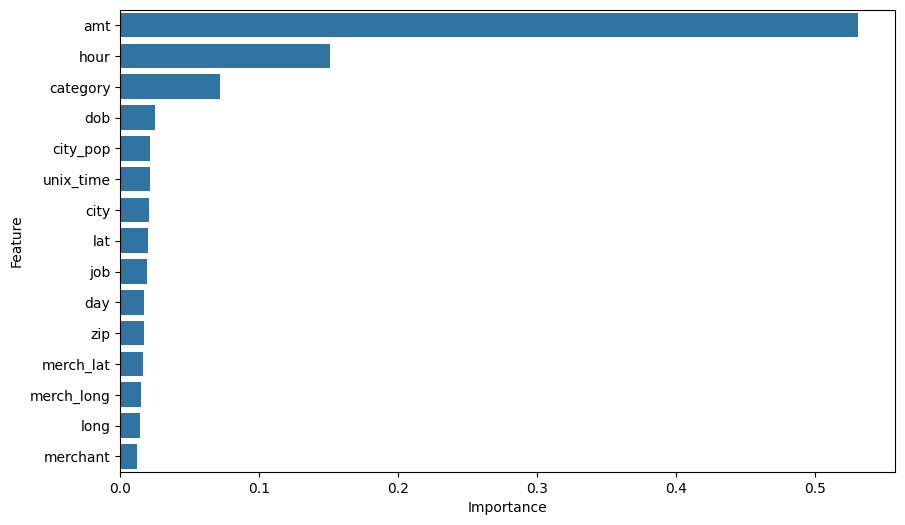

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.show()

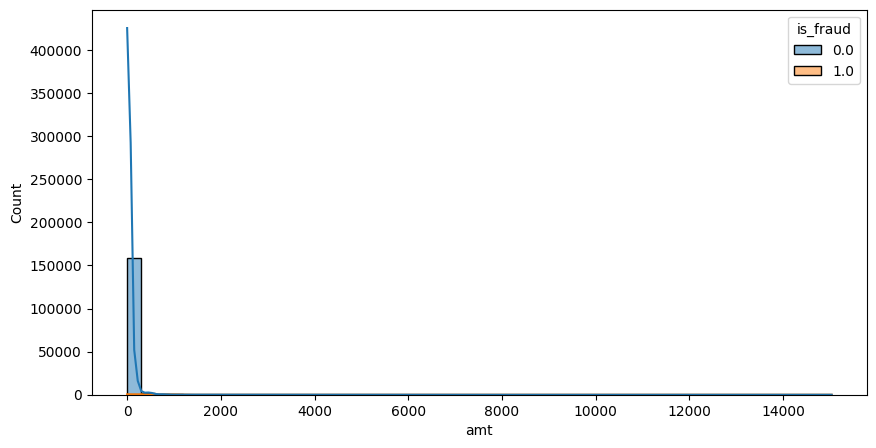

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=train_df,
    x='amt',
    hue='is_fraud',
    bins=50,
    kde=True
)

plt.show()

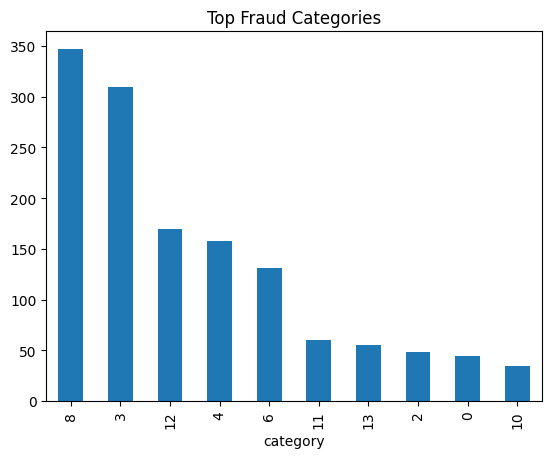

In [42]:
fraud_df = train_df[train_df["is_fraud"] == 1]

fraud_df["category"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Fraud Categories")
plt.show()

In [45]:
# The 'trans_date_trans_time' column was dropped in cell 'lznFk6hwTU5q',
# and the 'hour' column was already created in cell '6cLLArL2TU_W'.
# This cell is therefore redundant.
# train_df["hour"] = pd.to_datetime(
#     train_df["trans_date_trans_time"]
# ).dt.hour

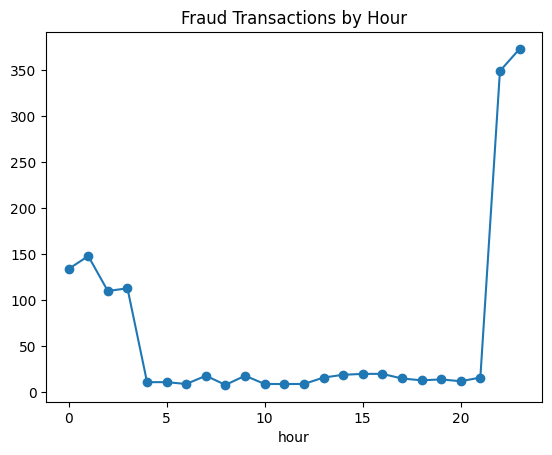

In [46]:
fraud_hour = train_df.groupby(
    "hour"
)["is_fraud"].sum()

fraud_hour.plot(
    kind="line",
    marker="o"
)

plt.title("Fraud Transactions by Hour")
plt.show()

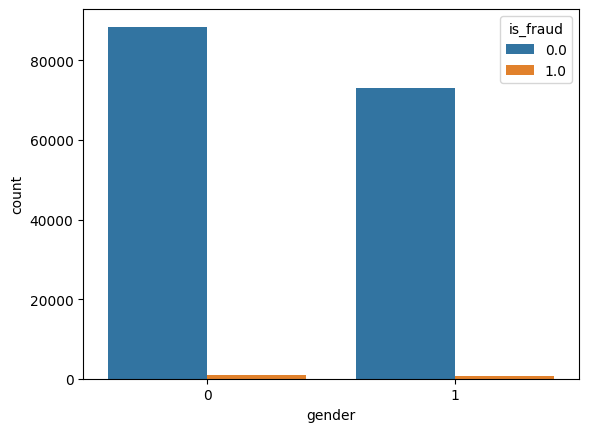

In [47]:
sns.countplot(
    x="gender",
    hue="is_fraud",
    data=train_df
)

plt.show()

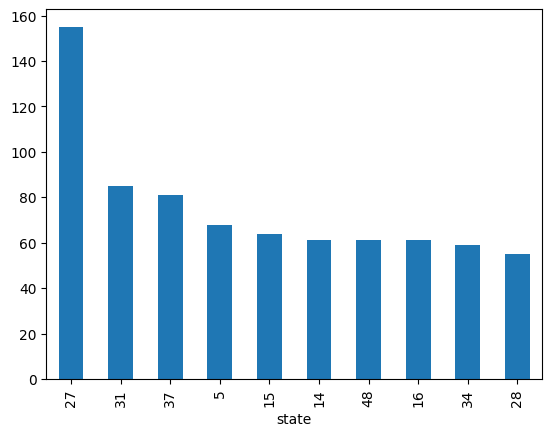

In [48]:
top_states = train_df.groupby(
    "state"
)["is_fraud"].sum().sort_values(
    ascending=False
).head(10)

top_states.plot(kind="bar")
plt.show()

In [49]:
train_df["dob"] = pd.to_datetime(train_df["dob"])

train_df["age"] = (
    pd.Timestamp.now().year
    - train_df["dob"].dt.year
)

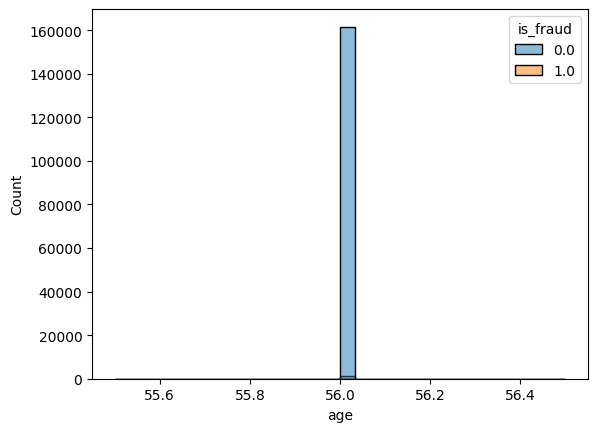

In [50]:
sns.histplot(
    data=train_df,
    x="age",
    hue="is_fraud",
    bins=30
)

plt.show()

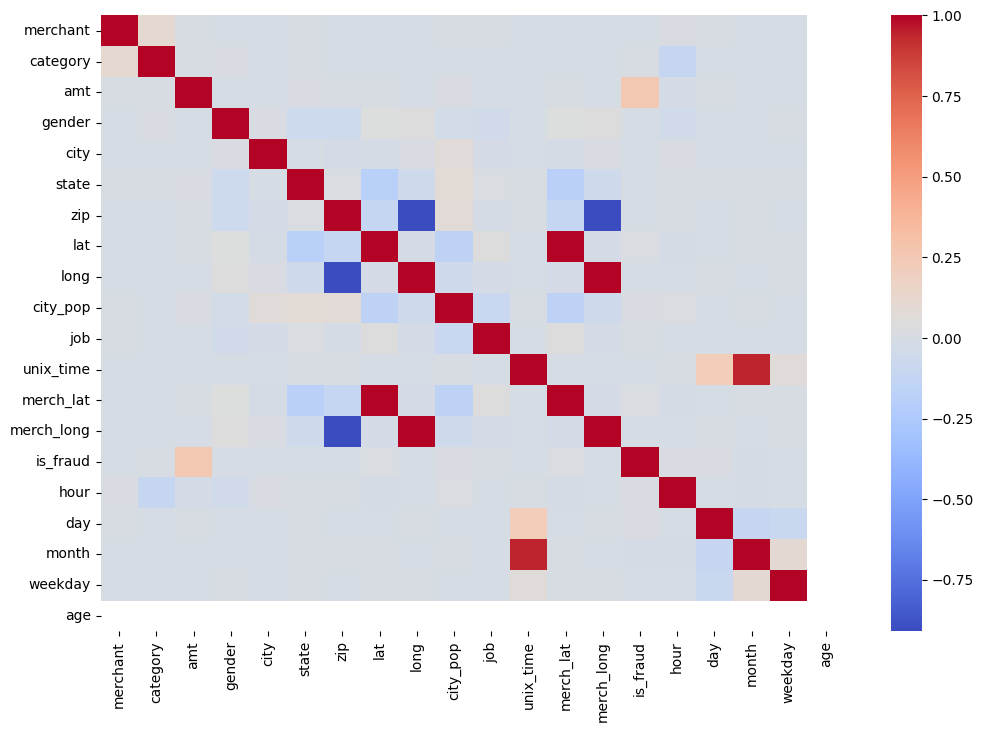

In [51]:
plt.figure(figsize=(12,8))

corr = train_df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

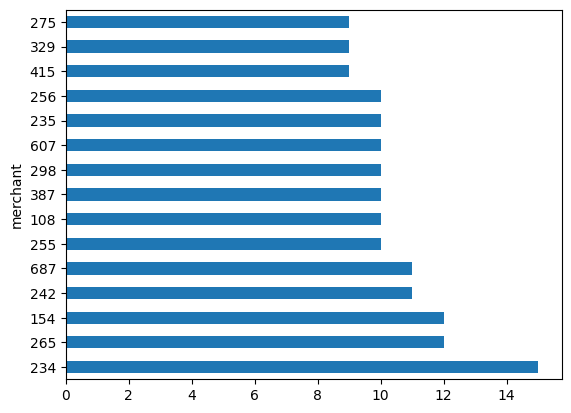

In [52]:
fraud_merchants = train_df[
    train_df["is_fraud"] == 1
]["merchant"].value_counts().head(15)

fraud_merchants.plot(
    kind="barh"
)

plt.show()

In [53]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

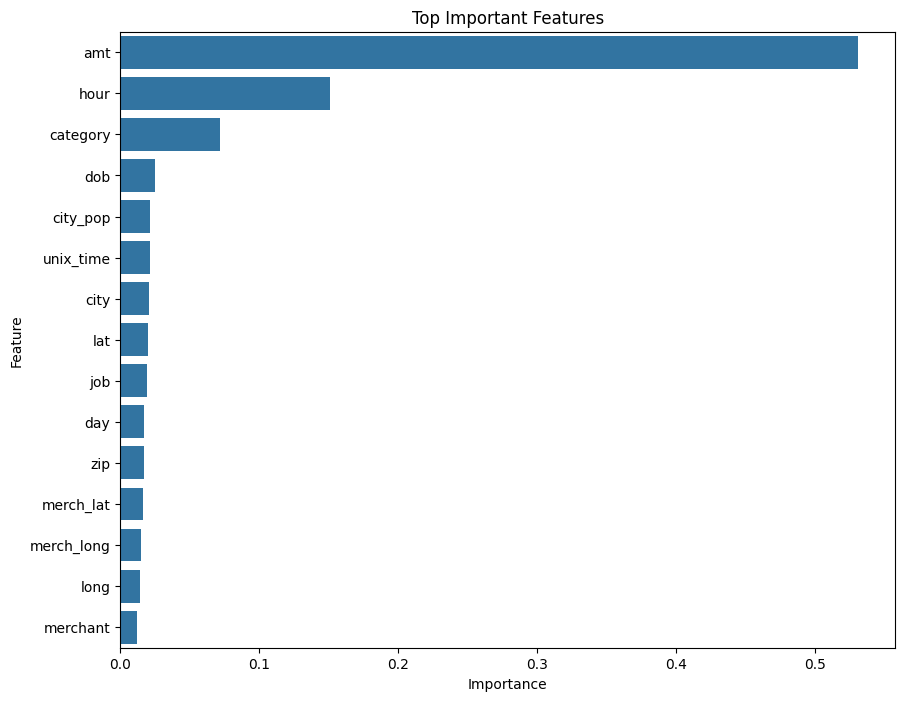

In [54]:
plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.title("Top Important Features")
plt.show()